In [1]:
import pandas as pd

training_df = pd.read_csv(
    "../data/processed/amazon_training_data.csv"
)

print("Training examples:", len(training_df))
print(training_df["intent"].value_counts())

Training examples: 567
intent
delivery_issue                  148
other_support                    81
refund                           46
return_replacement               43
account_access                   36
payment_billing                  33
order_status                     32
order_cancellation               29
prime_membership                 28
product_availability_pricing     24
product_issue                    24
seller_marketplace               23
delivery_address_options         20
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split

X = training_df["text"]
y = training_df["intent"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", len(X_train))
print("Test:", len(X_test))

Training: 453
Test: 114


In [3]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=42
        )
    )
])

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [4]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall: {recall:.4f}")
print(f"Macro F1: {f1:.4f}")

print("\nDetailed report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Accuracy: 0.3772
Macro Precision: 0.3372
Macro Recall: 0.3714
Macro F1: 0.3359

Detailed report:
                              precision    recall  f1-score   support

              account_access       0.33      0.43      0.38         7
    delivery_address_options       0.00      0.00      0.00         4
              delivery_issue       0.46      0.37      0.41        30
          order_cancellation       0.33      0.50      0.40         6
                order_status       0.22      0.33      0.27         6
               other_support       0.46      0.38      0.41        16
             payment_billing       0.67      0.29      0.40         7
            prime_membership       0.30      0.50      0.38         6
product_availability_pricing       0.33      0.40      0.36         5
               product_issue       0.00      0.00      0.00         5
                      refund       0.40      0.22      0.29         9
          return_replacement       0.38      0.67      0.48   

In [5]:
model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, min_df=2, ngram_range=(1, 2),
                                 sublinear_tf=True)),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=3000,
                                    random_state=42))])

In [6]:
import joblib
from pathlib import Path

model_dir = Path("../models")
model_dir.mkdir(exist_ok=True)

model_path = model_dir / "intent_classifier.joblib"

joblib.dump(model, model_path)

print(f"Model saved to: {model_path}")

Model saved to: ..\models\intent_classifier.joblib


In [8]:
from pathlib import Path

model_path = Path("../models/intent_classifier.joblib")

print("Expected path:", model_path.resolve())
print("Exists:", model_path.exists())

Expected path: C:\Users\sujat\OneDrive\Desktop\Hiver\models\intent_classifier.joblib
Exists: True


In [9]:
import joblib

model = joblib.load("../models/intent_classifier.joblib")

print("Model loaded successfully!")

Model loaded successfully!


In [10]:
import joblib
from pathlib import Path

model_dir = Path("../models")
model_dir.mkdir(exist_ok=True)

model_path = model_dir / "intent_classifier.joblib"

joblib.dump(model, model_path)

print(f"Model saved to: {model_path.resolve()}")

Model saved to: C:\Users\sujat\OneDrive\Desktop\Hiver\models\intent_classifier.joblib


In [11]:
print(model_path.exists())

True


In [13]:
joblib.load("../models/intent_classifier.joblib")

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, min_df=2, ngram_range=(1, 2),
                                 sublinear_tf=True)),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=3000,
                                    random_state=42))])

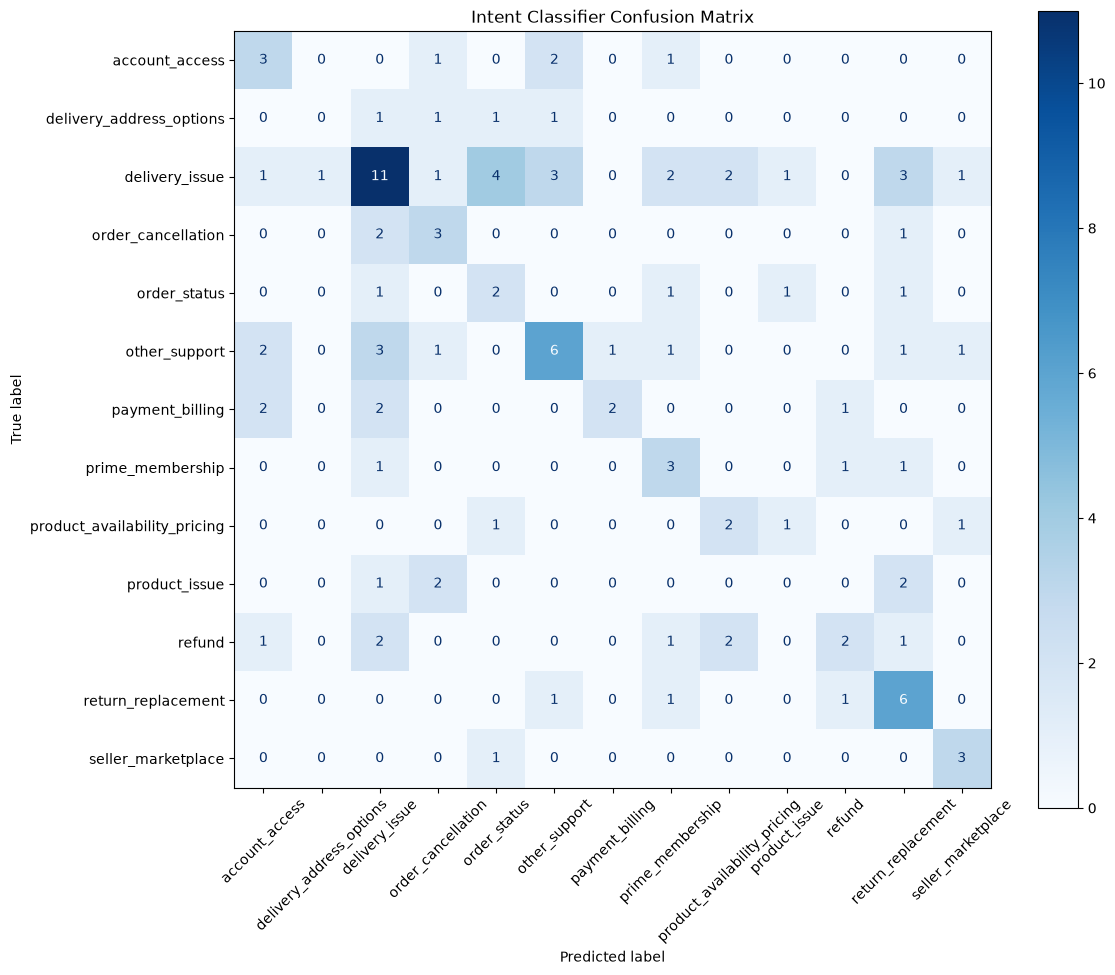

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45,
    cmap="Blues",
    ax=ax
)

plt.title("Intent Classifier Confusion Matrix")
plt.tight_layout()
plt.show()

In [15]:
results = pd.DataFrame({
    "text": X_test.values,
    "actual": y_test.values,
    "predicted": y_pred
})

results["correct"] = results["actual"] == results["predicted"]

print("Correct:", results["correct"].sum())
print("Incorrect:", (~results["correct"]).sum())

display(
    results[~results["correct"]]
    .head(30)
)

Correct: 43
Incorrect: 71


,text,actual,predicted,correct
0,@AmazonHelp My order 404-2520572-2629964. Arts...,product_issue,order_cancellation,False
2,@AmazonHelp Im not returning this cause the sh...,product_issue,return_replacement,False
3,@AmazonHelp Okay waiting to hear back. There h...,return_replacement,refund,False
4,@AmazonHelp At 23.55 the system said I request...,delivery_issue,order_cancellation,False
7,"@AmazonHelp Ordered two fire TV sticks, 100% c...",order_cancellation,delivery_issue,False
8,"@AmazonHelp Thanks, I don't want to return it ...",product_issue,return_replacement,False
11,@AmazonHelp What is the purpose of having amaz...,product_issue,delivery_issue,False
12,"@AmazonHelp Hi, this just sent me to the Ameri...",other_support,account_access,False
14,@AmazonHelp What’s your verdict?,other_support,delivery_issue,False
15,@AmazonHelp I ordered from .com,other_support,account_access,False


In [16]:
results = pd.DataFrame({
    "text": X_test.values,
    "actual": y_test.values,
    "predicted": y_pred
})

results["correct"] = results["actual"] == results["predicted"]

print("Correct:", results["correct"].sum())
print("Incorrect:", (~results["correct"]).sum())

Correct: 43
Incorrect: 71


In [17]:
errors = results[~results["correct"]].copy()

display(
    errors[
        ["text", "actual", "predicted"]
    ].head(30)
)

,text,actual,predicted
0,@AmazonHelp My order 404-2520572-2629964. Arts...,product_issue,order_cancellation
2,@AmazonHelp Im not returning this cause the sh...,product_issue,return_replacement
3,@AmazonHelp Okay waiting to hear back. There h...,return_replacement,refund
4,@AmazonHelp At 23.55 the system said I request...,delivery_issue,order_cancellation
7,"@AmazonHelp Ordered two fire TV sticks, 100% c...",order_cancellation,delivery_issue
8,"@AmazonHelp Thanks, I don't want to return it ...",product_issue,return_replacement
11,@AmazonHelp What is the purpose of having amaz...,product_issue,delivery_issue
12,"@AmazonHelp Hi, this just sent me to the Ameri...",other_support,account_access
14,@AmazonHelp What’s your verdict?,other_support,delivery_issue
15,@AmazonHelp I ordered from .com,other_support,account_access


In [18]:
error_pairs = (
    errors
    .groupby(["actual", "predicted"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(error_pairs)

,actual,predicted,count
10,delivery_issue,order_status,4
11,delivery_issue,other_support,3
15,delivery_issue,return_replacement,3
24,other_support,delivery_issue,3
12,delivery_issue,prime_membership,2
1,account_access,other_support,2
17,order_cancellation,delivery_issue,2
30,payment_billing,account_access,2
31,payment_billing,delivery_issue,2
23,other_support,account_access,2


In [19]:
baseline_metrics = {
    "accuracy": accuracy,
    "macro_precision": precision,
    "macro_recall": recall,
    "macro_f1": f1
}

print("Baseline model:")
for metric, value in baseline_metrics.items():
    print(f"{metric}: {value:.4f}")

Baseline model:
accuracy: 0.3772
macro_precision: 0.3372
macro_recall: 0.3714
macro_f1: 0.3359


In [20]:
from sklearn.svm import LinearSVC

svm_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LinearSVC(
            class_weight="balanced",
            random_state=42
        )
    )
])

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

svm_accuracy = accuracy_score(y_test, svm_pred)

svm_precision, svm_recall, svm_f1, _ = (
    precision_recall_fscore_support(
        y_test,
        svm_pred,
        average="macro",
        zero_division=0
    )
)

print(f"SVM Accuracy: {svm_accuracy:.4f}")
print(f"SVM Macro Precision: {svm_precision:.4f}")
print(f"SVM Macro Recall: {svm_recall:.4f}")
print(f"SVM Macro F1: {svm_f1:.4f}")

SVM Accuracy: 0.3772
SVM Macro Precision: 0.3301
SVM Macro Recall: 0.3344
SVM Macro F1: 0.3270


In [22]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy,
        svm_accuracy
    ],
    "Macro F1": [
        f1,
        svm_f1
    ]
})

display(comparison)

,Model,Accuracy,Macro F1
0,Logistic Regression,0.377193,0.335940
1,Linear SVM,0.377193,0.327018


In [23]:
from sklearn.pipeline import FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

word_tfidf = TfidfVectorizer(
    lowercase=True,
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

char_tfidf = TfidfVectorizer(
    lowercase=True,
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    sublinear_tf=True
)

combined_model = Pipeline([
    (
        "features",
        FeatureUnion([
            ("word", word_tfidf),
            ("char", char_tfidf)
        ])
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=42
        )
    )
])

combined_model.fit(X_train, y_train)

combined_pred = combined_model.predict(X_test)

In [24]:
combined_accuracy = accuracy_score(
    y_test,
    combined_pred
)

combined_precision, combined_recall, combined_f1, _ = (
    precision_recall_fscore_support(
        y_test,
        combined_pred,
        average="macro",
        zero_division=0
    )
)

print(f"Combined TF-IDF Accuracy: {combined_accuracy:.4f}")
print(f"Combined TF-IDF Macro Precision: {combined_precision:.4f}")
print(f"Combined TF-IDF Macro Recall: {combined_recall:.4f}")
print(f"Combined TF-IDF Macro F1: {combined_f1:.4f}")

Combined TF-IDF Accuracy: 0.4825
Combined TF-IDF Macro Precision: 0.4134
Combined TF-IDF Macro Recall: 0.4235
Combined TF-IDF Macro F1: 0.4145


In [25]:
comparison = pd.DataFrame({
    "Model": [
        "Word TF-IDF + Logistic Regression",
        "Word TF-IDF + Linear SVM",
        "Word + Character TF-IDF + Logistic Regression"
    ],
    "Accuracy": [
        accuracy,
        svm_accuracy,
        combined_accuracy
    ],
    "Macro F1": [
        f1,
        svm_f1,
        combined_f1
    ]
})

display(comparison)

,Model,Accuracy,Macro F1
0,Word TF-IDF + Logistic Regression,0.377193,0.335940
1,Word TF-IDF + Linear SVM,0.377193,0.327018
2,Word + Character TF-IDF + Logistic Regression,0.482456,0.414512


In [26]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        combined_pred,
        zero_division=0
    )
)

                              precision    recall  f1-score   support

              account_access       0.50      0.43      0.46         7
    delivery_address_options       0.00      0.00      0.00         4
              delivery_issue       0.52      0.57      0.54        30
          order_cancellation       0.38      0.50      0.43         6
                order_status       0.50      0.50      0.50         6
               other_support       0.56      0.62      0.59        16
             payment_billing       0.50      0.29      0.36         7
            prime_membership       0.43      0.50      0.46         6
product_availability_pricing       0.50      0.60      0.55         5
               product_issue       0.00      0.00      0.00         5
                      refund       0.33      0.33      0.33         9
          return_replacement       0.67      0.67      0.67         9
          seller_marketplace       0.50      0.50      0.50         4

                  

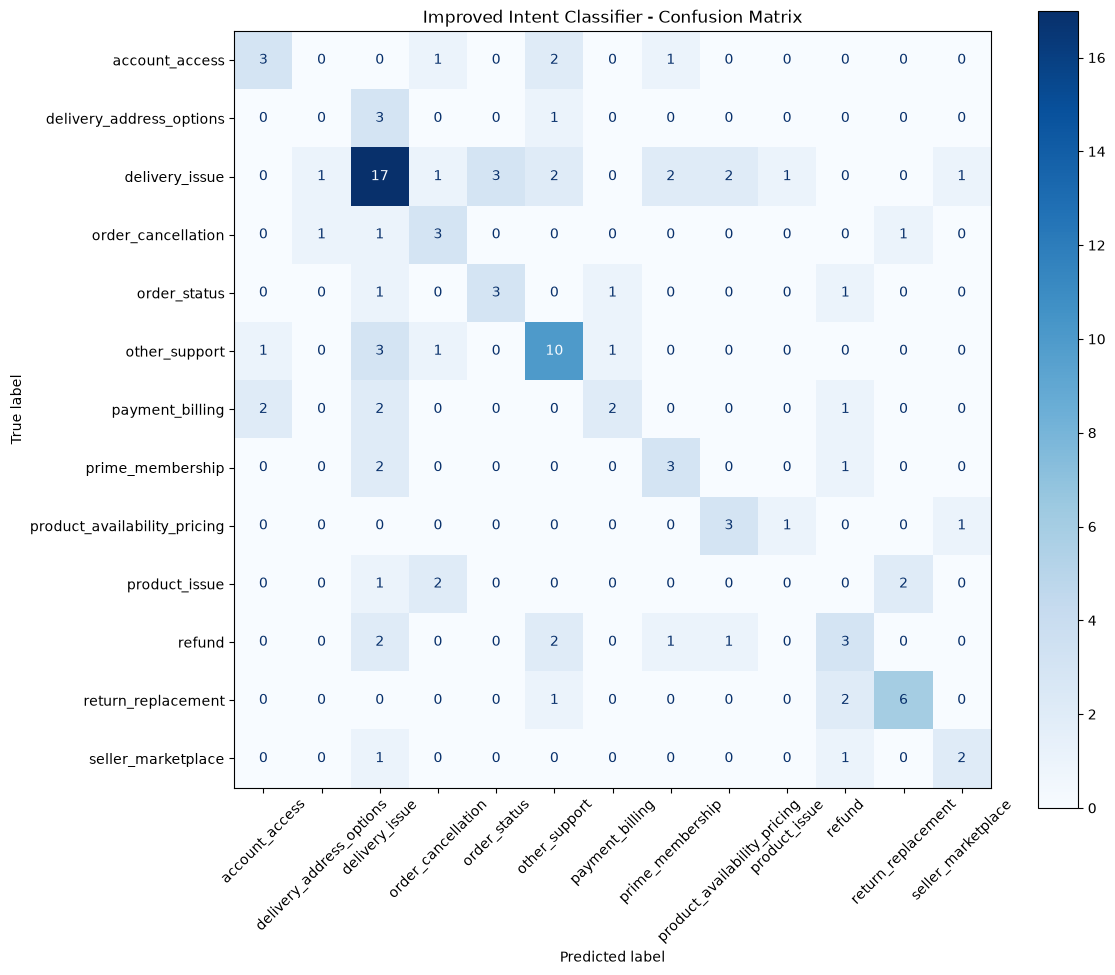

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    combined_pred,
    xticks_rotation=45,
    cmap="Blues",
    ax=ax
)

plt.title("Improved Intent Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()

In [28]:
improved_results = pd.DataFrame({
    "text": X_test.values,
    "actual": y_test.values,
    "predicted": combined_pred
})

improved_results["correct"] = (
    improved_results["actual"] ==
    improved_results["predicted"]
)

print("Correct:", improved_results["correct"].sum())
print("Incorrect:", (~improved_results["correct"]).sum())

display(
    improved_results[
        ~improved_results["correct"]
    ].head(30)
)

Correct: 55
Incorrect: 59


,text,actual,predicted,correct
0,@AmazonHelp My order 404-2520572-2629964. Arts...,product_issue,order_cancellation,False
2,@AmazonHelp Im not returning this cause the sh...,product_issue,return_replacement,False
3,@AmazonHelp Okay waiting to hear back. There h...,return_replacement,refund,False
4,@AmazonHelp At 23.55 the system said I request...,delivery_issue,order_cancellation,False
7,"@AmazonHelp Ordered two fire TV sticks, 100% c...",order_cancellation,delivery_address_options,False
8,"@AmazonHelp Thanks, I don't want to return it ...",product_issue,return_replacement,False
11,@AmazonHelp What is the purpose of having amaz...,product_issue,delivery_issue,False
15,@AmazonHelp I ordered from .com,other_support,account_access,False
16,@AmazonHelp The product wasn't damaged but tha...,delivery_issue,product_issue,False
17,"@AmazonHelp ""Please follow bellow instructions...",payment_billing,account_access,False


In [29]:
improved_errors = improved_results[
    ~improved_results["correct"]
]

error_pairs = (
    improved_errors
    .groupby(["actual", "predicted"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(error_pairs)

,actual,predicted,count
3,delivery_address_options,delivery_issue,3
7,delivery_issue,order_status,3
20,other_support,delivery_issue,3
1,account_access,other_support,2
8,delivery_issue,other_support,2
10,delivery_issue,product_availability_pricing,2
24,payment_billing,delivery_issue,2
9,delivery_issue,prime_membership,2
23,payment_billing,account_access,2
33,refund,delivery_issue,2
